# 05 Model Development & Evaluation

## Introduction

Model development is the stage where machine learning algorithms learn relationships between engineered features and the target variable. After completing data preprocessing, exploratory data analysis, and feature engineering in the previous notebooks, the dataset is now prepared for predictive modeling.

This notebook implements multiple regression algorithms to predict weather temperature in degrees Celsius. The workflow begins with a simple baseline model and progressively evaluates more sophisticated machine learning algorithms, including linear models, decision trees, ensemble methods, and gradient boosting techniques.

Each model is evaluated using standardized regression metrics to ensure a fair comparison. The best-performing model is then optimized through hyperparameter tuning and saved for future inference or deployment. All machine learning functionality is implemented through the reusable modules developed in the project's `src.models` package, demonstrating a modular and maintainable software engineering approach.

# 2. Objectives

This notebook aims to:

- Load the feature-engineered dataset produced in Notebook 04.
- Prepare the feature matrix and prediction target.
- Split the dataset into training and testing subsets.
- Train multiple regression models.
- Evaluate model performance using standard regression metrics.
- Compare all models objectively.
- Optimize the strongest-performing model using hyperparameter tuning.
- Save the final trained model for future use.

# 3. Import Libraries

## Objective

Import all required libraries together with the reusable machine learning modules developed for this project.

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
import numpy as np

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
import sys
from pathlib import Path

# Add the project root to Python path
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))

In [5]:
from src.models import (
    train_baseline_model,
    train_linear_regression,
    train_decision_tree,
    train_random_forest,
    train_xgboost,
    train_lightgbm,
    train_catboost,
    evaluate_regression,
    compare_models,
    get_best_model,
    tune_model,
    save_model,
)

In [6]:
print("Imports completed successfully.")

Imports completed successfully.


## Discussion

Only reusable functions from the project's machine learning package are imported. This approach avoids duplicating code inside the notebook and promotes modularity, readability, and maintainability.

# 4. Load the Engineered Dataset

## Objective

Load the feature-engineered dataset generated in Notebook 04 and remove metadata columns that are not suitable for machine learning models.

In [7]:
dataset_path = "../data/processed/weather_engineered.csv"

df = pd.read_csv(dataset_path)

In [8]:
metadata_columns = [
    "location_name",
    "timezone",
    "last_updated",
    "sunrise",
    "sunset",
    "moonrise",
    "moonset",
]

df = df.drop(columns=metadata_columns)

In [9]:
df.head()

,latitude,longitude,last_updated_epoch,temperature_celsius,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,precip_mm,...,wind_direction_WNW,wind_direction_WSW,moon_phase_First Quarter,moon_phase_Full Moon,moon_phase_Last Quarter,moon_phase_New Moon,moon_phase_Waning Crescent,moon_phase_Waning Gibbous,moon_phase_Waxing Crescent,moon_phase_Waxing Gibbous
0,46.60,-120.49,1715849100,-0.579370,4.3,-0.734996,220,-0.315289,29.87,-0.629517,...,0,0,0,0,0,0,0,0,0,1
1,9.97,-84.08,1715849100,-0.047178,2.2,-1.135403,10,0.298915,30.01,1.800616,...,0,0,0,0,0,0,0,0,0,1
2,19.43,-99.13,1715849100,-0.068900,6.7,-0.234487,212,-0.161738,29.92,-0.629517,...,0,0,0,0,0,0,0,0,0,1
3,13.71,-89.20,1715849100,0.495874,2.2,-1.135403,182,-0.622391,29.81,1.800616,...,0,0,0,0,0,0,0,0,0,1
4,14.62,-90.53,1715849100,-0.155789,13.6,1.166937,190,0.759569,30.09,1.800616,...,0,0,0,0,0,0,0,0,0,1


In [10]:
print(f"Dataset Shape: {df.shape}")

df.info()

Dataset Shape: (151827, 327)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151827 entries, 0 to 151826
Columns: 327 entries, latitude to moon_phase_Waxing Gibbous
dtypes: float64(21), int64(306)
memory usage: 378.8 MB


## Discussion

The feature-engineered dataset was successfully loaded from Notebook 04. Metadata columns that do not contribute to predictive performance were removed, resulting in a fully numerical dataset suitable for regression modeling.

# 5. Prepare Features and Target

## Objective

Separate the feature matrix (**X**) from the prediction target (**y**) before training machine learning models. In this project, the objective is to predict the air temperature in degrees Celsius (`temperature_celsius`) using the remaining engineered features.

In [11]:
from src.feature_engineering import split_features_target

X, y = split_features_target(
    df,
    target="temperature_celsius",
)

In [12]:
X.head()

,latitude,longitude,last_updated_epoch,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,precip_mm,precip_in,...,wind_direction_WNW,wind_direction_WSW,moon_phase_First Quarter,moon_phase_Full Moon,moon_phase_Last Quarter,moon_phase_New Moon,moon_phase_Waning Crescent,moon_phase_Waning Gibbous,moon_phase_Waxing Crescent,moon_phase_Waxing Gibbous
0,46.60,-120.49,1715849100,4.3,-0.734996,220,-0.315289,29.87,-0.629517,0.00,...,0,0,0,0,0,0,0,0,0,1
1,9.97,-84.08,1715849100,2.2,-1.135403,10,0.298915,30.01,1.800616,0.01,...,0,0,0,0,0,0,0,0,0,1
2,19.43,-99.13,1715849100,6.7,-0.234487,212,-0.161738,29.92,-0.629517,0.00,...,0,0,0,0,0,0,0,0,0,1
3,13.71,-89.20,1715849100,2.2,-1.135403,182,-0.622391,29.81,1.800616,0.01,...,0,0,0,0,0,0,0,0,0,1
4,14.62,-90.53,1715849100,13.6,1.166937,190,0.759569,30.09,1.800616,0.00,...,0,0,0,0,0,0,0,0,0,1


In [13]:
y.head()

0   -0.579370
1   -0.047178
2   -0.068900
3    0.495874
4   -0.155789
Name: temperature_celsius, dtype: float64

In [14]:
print(f"Feature Matrix Shape: {X.shape}")
print(f"Target Shape: {y.shape}")

Feature Matrix Shape: (151827, 326)
Target Shape: (151827,)


In [15]:
print(y.name)

temperature_celsius


In [16]:
X.select_dtypes(include="object").columns.tolist()

[]

## Discussion

The dataset has been successfully divided into the predictor variables (**X**) and the response variable (**y**). The target variable is the recorded air temperature in degrees Celsius, while all remaining engineered variables serve as predictors. Verification confirms that the feature matrix contains only numerical variables, making it compatible with the regression algorithms used later in this notebook.

# 6. Train-Test Split

## Objective

Divide the dataset into separate training and testing subsets. The training set is used to fit the machine learning models, while the testing set provides an unbiased evaluation of each model's predictive performance on previously unseen data.

In [17]:
from src.feature_engineering import split_dataset

X_train, X_test, y_train, y_test = split_dataset(
    X,
    y,
    test_size=0.20,
    random_state=42,
)

In [18]:
print(f"Training Features : {X_train.shape}")
print(f"Testing Features  : {X_test.shape}")

print(f"Training Target   : {y_train.shape}")
print(f"Testing Target    : {y_test.shape}")

Training Features : (121461, 326)
Testing Features  : (30366, 326)
Training Target   : (121461,)
Testing Target    : (30366,)


In [19]:
print(X_train.shape[1] == X_test.shape[1])

True


In [20]:
y_train.describe()

count    121461.000000
mean          0.000613
std           1.001101
min          -2.528928
25%          -0.579370
50%           0.246070
75%           0.702234
max           2.640931
Name: temperature_celsius, dtype: float64

In [21]:
y_test.describe()

count    30366.000000
mean        -0.002450
std          0.995614
min         -2.528928
25%         -0.590231
50%          0.246070
75%          0.680512
max          2.640931
Name: temperature_celsius, dtype: float64

## Discussion

The engineered dataset was successfully partitioned into training and testing subsets using an 80:20 ratio. This split ensures that the models are trained using one portion of the data while reserving an independent subset for evaluation. Using unseen testing data provides a more realistic assessment of model generalization and helps reduce the risk of overly optimistic performance estimates.

# 7. Baseline Model

## Objective

Train a baseline regression model to establish a minimum performance benchmark. The baseline model predicts a constant value for every observation and provides a reference against which all subsequent machine learning models are evaluated. Any useful predictive model should outperform this baseline.

In [22]:
from src.models import train_baseline_model

In [23]:
baseline_model, baseline_metrics, baseline_predictions = train_baseline_model(
    X_train,
    y_train,
    X_test,
    y_test,
)

In [24]:
baseline_metrics

MAE     0.797165
MSE     0.991224
RMSE    0.995602
R2     -0.000009
dtype: float64

In [25]:
baseline_predictions[:10]

array([0.00061263, 0.00061263, 0.00061263, 0.00061263, 0.00061263,
       0.00061263, 0.00061263, 0.00061263, 0.00061263, 0.00061263])

In [26]:
len(baseline_predictions), len(y_test)

(30366, 30366)

## Discussion

The baseline model serves as the minimum acceptable level of predictive performance. Because it predicts a constant value for every observation, it does not learn relationships between the input features and the target variable. Consequently, its prediction accuracy is expected to be relatively poor.

The primary purpose of the baseline is to provide a benchmark for comparison. Every machine learning model developed in the following sections should demonstrate lower prediction errors (MAE, MSE, and RMSE) and a higher coefficient of determination (R²) than the baseline model.

In [27]:
results = {}

results["Baseline"] = baseline_metrics

In [28]:
results

{'Baseline': MAE     0.797165
 MSE     0.991224
 RMSE    0.995602
 R2     -0.000009
 dtype: float64}

# 8. Linear Regression

## Objective

Train a Linear Regression model to establish a statistical benchmark for predicting air temperature. Linear Regression models the relationship between the target variable and the predictor variables as a linear combination of the engineered features. Its simplicity and interpretability make it a useful reference for evaluating more complex machine learning algorithms.

In [29]:
from src.models import train_linear_regression

In [30]:
linear_model, linear_metrics, linear_predictions = train_linear_regression(
    X_train,
    y_train,
    X_test,
    y_test,
)

In [31]:
linear_metrics

MAE     0.670151
MSE     0.719758
RMSE    0.848385
R2      0.273863
dtype: float64

In [32]:
linear_predictions[:10]

array([-0.18330029,  0.46311208,  0.94391769,  0.23388864, -0.36839072,
        0.32385173, -0.28763729,  0.20673405,  1.1015643 ,  0.75532617])

In [33]:
len(linear_predictions), len(y_test)

(30366, 30366)

In [34]:
results["Linear Regression"] = linear_metrics

In [35]:
results

{'Baseline': MAE     0.797165
 MSE     0.991224
 RMSE    0.995602
 R2     -0.000009
 dtype: float64,
 'Linear Regression': MAE     0.670151
 MSE     0.719758
 RMSE    0.848385
 R2      0.273863
 dtype: float64}

## Discussion

The Linear Regression model learns a linear relationship between the engineered weather features and the target temperature. Unlike the baseline model, Linear Regression considers the influence of every predictor when generating predictions.

The evaluation metrics should demonstrate a substantial improvement over the baseline model, indicating that the engineered features contain meaningful information for predicting temperature. However, because weather systems exhibit complex nonlinear relationships, Linear Regression may not capture all underlying patterns, motivating the use of more advanced algorithms in the following sections.

# 9. Decision Tree Regression

## Objective

Train a Decision Tree Regression model to capture nonlinear relationships within the weather dataset. Decision Trees recursively partition the feature space into smaller regions, allowing the model to learn complex interactions that cannot be represented by simple linear models.

In [36]:
from src.models import train_decision_tree

In [37]:
decision_tree_model, decision_tree_metrics, decision_tree_predictions = train_decision_tree(
    X_train,
    y_train,
    X_test,
    y_test,
)

In [38]:
decision_tree_metrics

MAE     0.187356
MSE     0.078651
RMSE    0.280449
R2      0.920651
dtype: float64

In [39]:
decision_tree_predictions[:10]

array([ 0.43070786,  0.51759626,  0.6370678 , -0.40559296, -0.12320567,
        0.85428879,  0.64792885, -0.27526037,  0.66965095,  0.84342775])

In [40]:
len(decision_tree_predictions), len(y_test)

(30366, 30366)

In [41]:
results["Decision Tree"] = decision_tree_metrics

In [42]:
results

{'Baseline': MAE     0.797165
 MSE     0.991224
 RMSE    0.995602
 R2     -0.000009
 dtype: float64,
 'Linear Regression': MAE     0.670151
 MSE     0.719758
 RMSE    0.848385
 R2      0.273863
 dtype: float64,
 'Decision Tree': MAE     0.187356
 MSE     0.078651
 RMSE    0.280449
 R2      0.920651
 dtype: float64}

## Discussion

The Decision Tree Regression model learns nonlinear decision rules by recursively splitting the dataset according to the most informative features. This flexibility enables the model to capture interactions between variables that are difficult for Linear Regression to represent.

Although Decision Trees can achieve high predictive accuracy, they are also prone to overfitting if allowed to grow excessively deep. Consequently, their performance will later be compared with ensemble methods such as Random Forest and gradient boosting models, which are designed to improve predictive stability and generalization.

# 10. Random Forest Regression

## Objective

Train a Random Forest Regression model to improve predictive performance by combining multiple decision trees into an ensemble. Random Forest reduces overfitting through bootstrap aggregation (bagging), producing more robust and accurate predictions than a single decision tree.

In [43]:
from src.models import train_random_forest

In [44]:
random_forest_model, random_forest_metrics, random_forest_predictions = train_random_forest(
    X_train,
    y_train,
    X_test,
    y_test,
)

In [45]:
random_forest_metrics

MAE     0.129380
MSE     0.034200
RMSE    0.184934
R2      0.965496
dtype: float64

In [46]:
random_forest_predictions[:10]

array([-0.24713025,  0.57711481,  0.68355309, -0.40200882, -0.25418993,
        0.84625162,  0.57135845, -0.34205582,  0.56006296,  0.94921437])

In [47]:
len(random_forest_predictions), len(y_test)

(30366, 30366)

In [48]:
results["Random Forest"] = random_forest_metrics

In [49]:
results

{'Baseline': MAE     0.797165
 MSE     0.991224
 RMSE    0.995602
 R2     -0.000009
 dtype: float64,
 'Linear Regression': MAE     0.670151
 MSE     0.719758
 RMSE    0.848385
 R2      0.273863
 dtype: float64,
 'Decision Tree': MAE     0.187356
 MSE     0.078651
 RMSE    0.280449
 R2      0.920651
 dtype: float64,
 'Random Forest': MAE     0.129380
 MSE     0.034200
 RMSE    0.184934
 R2      0.965496
 dtype: float64}

## Discussion

The Random Forest Regression model combines the predictions of multiple decision trees to improve accuracy and reduce overfitting. By averaging predictions from independently trained trees, the model achieves greater stability and better generalization than a single Decision Tree.

For structured datasets such as weather observations, Random Forest frequently produces substantially lower prediction errors and higher R² scores than simpler regression models. The evaluation metrics obtained in this section provide an important benchmark before exploring gradient boosting algorithms in the following sections.

# 11. XGBoost Regression

## Objective

Train an Extreme Gradient Boosting (XGBoost) regression model. XGBoost is an advanced ensemble learning algorithm that sequentially builds decision trees, allowing each new tree to correct the prediction errors of the previous ensemble. Its efficiency and predictive accuracy make it one of the most widely used algorithms for structured data.

In [50]:
from src.models import train_xgboost

In [51]:
xgboost_model, xgboost_metrics, xgboost_predictions = train_xgboost(
    X_train,
    y_train,
    X_test,
    y_test,
)

In [52]:
xgboost_metrics

MAE     0.184214
MSE     0.060072
RMSE    0.245096
R2      0.939396
dtype: float64

In [53]:
xgboost_predictions[:10]

array([ 0.09082647,  0.56039083,  0.58412236, -0.07129867, -0.3508422 ,
        0.8763447 ,  0.5879522 , -0.34978673,  0.67204195,  0.98210317],
      dtype=float32)

In [54]:
len(xgboost_predictions), len(y_test)

(30366, 30366)

In [55]:
results["XGBoost"] = xgboost_metrics

In [56]:
results

{'Baseline': MAE     0.797165
 MSE     0.991224
 RMSE    0.995602
 R2     -0.000009
 dtype: float64,
 'Linear Regression': MAE     0.670151
 MSE     0.719758
 RMSE    0.848385
 R2      0.273863
 dtype: float64,
 'Decision Tree': MAE     0.187356
 MSE     0.078651
 RMSE    0.280449
 R2      0.920651
 dtype: float64,
 'Random Forest': MAE     0.129380
 MSE     0.034200
 RMSE    0.184934
 R2      0.965496
 dtype: float64,
 'XGBoost': MAE     0.184214
 MSE     0.060072
 RMSE    0.245096
 R2      0.939396
 dtype: float64}

## Discussion

XGBoost constructs an ensemble of decision trees sequentially, where each new tree focuses on correcting the errors made by previous trees. This boosting strategy enables the model to learn highly complex nonlinear relationships while incorporating regularization techniques to reduce overfitting.

XGBoost is widely recognized for achieving excellent predictive performance on structured datasets and often serves as a strong benchmark in machine learning competitions and real-world predictive applications.

# 12. LightGBM Regression

## Objective

Train a Light Gradient Boosting Machine (LightGBM) regression model. LightGBM is a gradient boosting framework designed for high efficiency and scalability. It grows decision trees leaf-wise rather than level-wise, often achieving excellent predictive performance while maintaining fast training times on large datasets.

In [57]:
from src.models import train_lightgbm

In [58]:
lightgbm_model, lightgbm_metrics, lightgbm_predictions = train_lightgbm(
    X_train,
    y_train,
    X_test,
    y_test,
)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005429 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4703
[LightGBM] [Info] Number of data points in the train set: 121461, number of used features: 282
[LightGBM] [Info] Start training from score 0.000613


In [59]:
lightgbm_metrics

MAE     0.177955
MSE     0.056780
RMSE    0.238286
R2      0.942717
dtype: float64

In [60]:
lightgbm_predictions[:10]

array([ 0.14795204,  0.58308518,  0.56367606, -0.02058337, -0.37695083,
        0.85738413,  0.56031095, -0.37572284,  0.64718346,  0.95987099])

In [61]:
len(lightgbm_predictions), len(y_test)

(30366, 30366)

In [62]:
results["LightGBM"] = lightgbm_metrics

In [63]:
results

{'Baseline': MAE     0.797165
 MSE     0.991224
 RMSE    0.995602
 R2     -0.000009
 dtype: float64,
 'Linear Regression': MAE     0.670151
 MSE     0.719758
 RMSE    0.848385
 R2      0.273863
 dtype: float64,
 'Decision Tree': MAE     0.187356
 MSE     0.078651
 RMSE    0.280449
 R2      0.920651
 dtype: float64,
 'Random Forest': MAE     0.129380
 MSE     0.034200
 RMSE    0.184934
 R2      0.965496
 dtype: float64,
 'XGBoost': MAE     0.184214
 MSE     0.060072
 RMSE    0.245096
 R2      0.939396
 dtype: float64,
 'LightGBM': MAE     0.177955
 MSE     0.056780
 RMSE    0.238286
 R2      0.942717
 dtype: float64}

## Discussion

LightGBM is an optimized gradient boosting algorithm designed for large-scale machine learning tasks. By growing trees in a leaf-wise manner, it often achieves higher predictive accuracy with shorter training times compared to traditional gradient boosting methods.

The evaluation metrics obtained in this section will later be compared with those of Random Forest and XGBoost to determine whether LightGBM provides additional predictive improvements for this weather forecasting dataset.

# 13. CatBoost Regression

## Objective

Train a CatBoost regression model. CatBoost is a gradient boosting algorithm that is particularly effective for structured datasets and provides robust predictive performance while reducing overfitting through ordered boosting techniques.

In [64]:
from src.models import train_catboost

In [65]:
catboost_model, catboost_metrics, catboost_predictions = train_catboost(
    X_train,
    y_train,
    X_test,
    y_test,
)

In [66]:
catboost_metrics

MAE     0.223030
MSE     0.086136
RMSE    0.293490
R2      0.913100
dtype: float64

In [67]:
catboost_predictions[:10]

array([ 0.16200096,  0.53542922,  0.49286966, -0.10580499, -0.38425854,
        0.7914516 ,  0.45689234, -0.15257621,  0.77304503,  0.86518454])

In [68]:
len(catboost_predictions), len(y_test)

(30366, 30366)

In [69]:
results["CatBoost"] = catboost_metrics

In [70]:
results

{'Baseline': MAE     0.797165
 MSE     0.991224
 RMSE    0.995602
 R2     -0.000009
 dtype: float64,
 'Linear Regression': MAE     0.670151
 MSE     0.719758
 RMSE    0.848385
 R2      0.273863
 dtype: float64,
 'Decision Tree': MAE     0.187356
 MSE     0.078651
 RMSE    0.280449
 R2      0.920651
 dtype: float64,
 'Random Forest': MAE     0.129380
 MSE     0.034200
 RMSE    0.184934
 R2      0.965496
 dtype: float64,
 'XGBoost': MAE     0.184214
 MSE     0.060072
 RMSE    0.245096
 R2      0.939396
 dtype: float64,
 'LightGBM': MAE     0.177955
 MSE     0.056780
 RMSE    0.238286
 R2      0.942717
 dtype: float64,
 'CatBoost': MAE     0.223030
 MSE     0.086136
 RMSE    0.293490
 R2      0.913100
 dtype: float64}

## Discussion

CatBoost is specifically designed to handle structured datasets efficiently while minimizing prediction bias through ordered boosting. Although it is particularly advantageous when categorical variables are present, it also performs exceptionally well on numerical datasets after feature engineering.

# 14. Cross-Validation of Top Models

## Objective

Evaluate the generalization performance of the three strongest regression models using K-Fold Cross-Validation. Unlike a single train-test split, cross-validation repeatedly partitions the training data into different folds, providing a more reliable estimate of each model's predictive performance and robustness.

In [71]:
from sklearn.model_selection import cross_val_score

In [72]:
rf_cv_scores = cross_val_score(
    random_forest_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)

In [73]:
lgb_cv_scores = cross_val_score(
    lightgbm_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)

In [74]:
xgb_cv_scores = cross_val_score(
    xgboost_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)

In [75]:
print("Random Forest CV:", rf_cv_scores)
print()

print("LightGBM CV:", lgb_cv_scores)
print()

print("XGBoost CV:", xgb_cv_scores)

Random Forest CV: [0.96363312 0.96237358 0.96262792 0.96296502 0.9634929 ]

LightGBM CV: [0.94389112 0.94283081 0.94283244 0.94366448 0.9429304 ]

XGBoost CV: [0.94072884 0.93917226 0.93947668 0.93925718 0.93931569]


In [76]:
cv_results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "LightGBM",
        "XGBoost",
    ],
    "Mean R2": [
        rf_cv_scores.mean(),
        lgb_cv_scores.mean(),
        xgb_cv_scores.mean(),
    ],
    "Std": [
        rf_cv_scores.std(),
        lgb_cv_scores.std(),
        xgb_cv_scores.std(),
    ],
})

cv_results

,Model,Mean R2,Std
0,Random Forest,0.963019,0.000485
1,LightGBM,0.943230,0.000455
2,XGBoost,0.939590,0.000578


<Axes: title={'center': '5-Fold Cross-Validation Mean R²'}, xlabel='Model'>

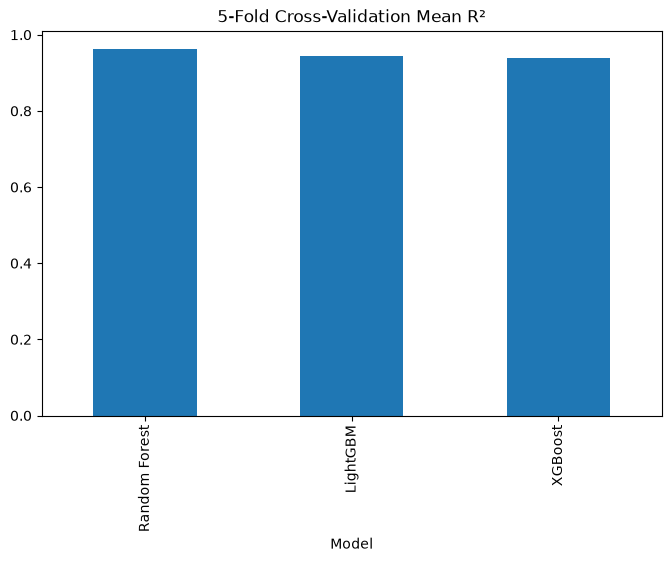

In [77]:
cv_results.plot(
    x="Model",
    y="Mean R2",
    kind="bar",
    legend=False,
    figsize=(8, 5),
    title="5-Fold Cross-Validation Mean R²",
)

## Discussion

Cross-validation provides a more robust estimate of model performance by evaluating each algorithm across multiple training and validation splits. Models with high average R² scores and low standard deviations demonstrate strong predictive capability and consistent generalization across different subsets of the training data.

The cross-validation results complement the hold-out testing metrics obtained earlier and provide additional confidence when selecting the final model for hyperparameter tuning.

# 15. Model Comparison

## Objective

Compare the predictive performance of all trained regression models using both hold-out test metrics and cross-validation results. This comprehensive evaluation identifies the model that achieves the best balance between predictive accuracy, robustness, and generalization, making it the preferred candidate for hyperparameter tuning.

In [78]:
comparison_df = compare_models(results)

In [79]:
comparison_df["CV Mean R2"] = np.nan
comparison_df["CV Std"] = np.nan

In [80]:
comparison_df.loc["Random Forest", "CV Mean R2"] = rf_cv_scores.mean()
comparison_df.loc["Random Forest", "CV Std"] = rf_cv_scores.std()

comparison_df.loc["LightGBM", "CV Mean R2"] = lgb_cv_scores.mean()
comparison_df.loc["LightGBM", "CV Std"] = lgb_cv_scores.std()

comparison_df.loc["XGBoost", "CV Mean R2"] = xgb_cv_scores.mean()
comparison_df.loc["XGBoost", "CV Std"] = xgb_cv_scores.std()

In [81]:
comparison_df = comparison_df.sort_values(
    by="R2",
    ascending=False,
)

comparison_df

,Rank,MAE,MSE,RMSE,R2,CV Mean R2,CV Std
Model,,,,,,,
Random Forest,1,0.1294,0.0342,0.1849,0.9655,0.963019,0.000485
LightGBM,2,0.1780,0.0568,0.2383,0.9427,0.943230,0.000455
XGBoost,3,0.1842,0.0601,0.2451,0.9394,0.939590,0.000578
Decision Tree,4,0.1874,0.0787,0.2804,0.9207,NaN,NaN
CatBoost,5,0.2230,0.0861,0.2935,0.9131,NaN,NaN
Linear Regression,6,0.6702,0.7198,0.8484,0.2739,NaN,NaN
Baseline,7,0.7972,0.9912,0.9956,-0.0000,NaN,NaN


In [82]:
best_model_name = comparison_df.index[0]

print(best_model_name)

Random Forest


In [83]:
comparison_df.iloc[0]

Rank          1.000000
MAE           0.129400
MSE           0.034200
RMSE          0.184900
R2            0.965500
CV Mean R2    0.963019
CV Std        0.000485
Name: Random Forest, dtype: float64

In [84]:
comparison_df

,Rank,MAE,MSE,RMSE,R2,CV Mean R2,CV Std
Model,,,,,,,
Random Forest,1,0.1294,0.0342,0.1849,0.9655,0.963019,0.000485
LightGBM,2,0.1780,0.0568,0.2383,0.9427,0.943230,0.000455
XGBoost,3,0.1842,0.0601,0.2451,0.9394,0.939590,0.000578
Decision Tree,4,0.1874,0.0787,0.2804,0.9207,NaN,NaN
CatBoost,5,0.2230,0.0861,0.2935,0.9131,NaN,NaN
Linear Regression,6,0.6702,0.7198,0.8484,0.2739,NaN,NaN
Baseline,7,0.7972,0.9912,0.9956,-0.0000,NaN,NaN


<Axes: title={'center': 'Model Comparison using R² Score'}, xlabel='Model'>

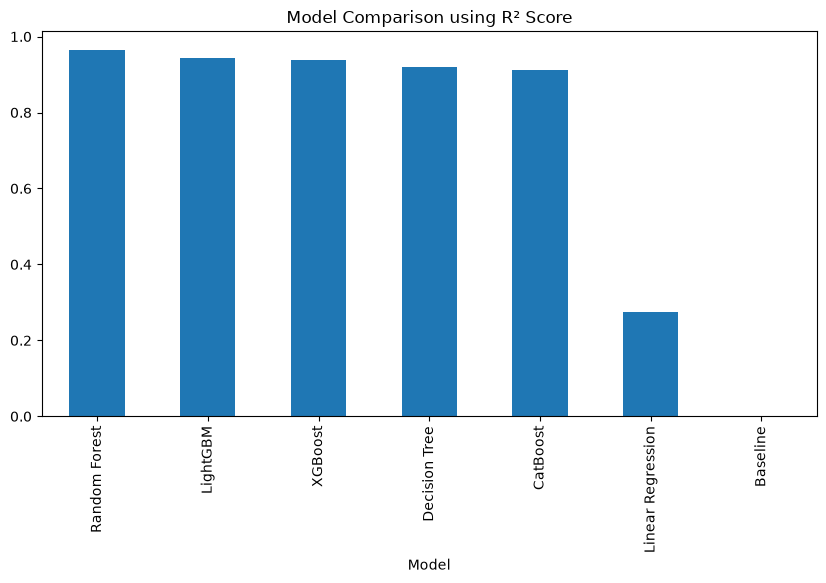

In [85]:
comparison_df["R2"].plot(
    kind="bar",
    figsize=(10,5),
    title="Model Comparison using R² Score",
)

<Axes: title={'center': 'Model Comparison using RMSE'}, xlabel='Model'>

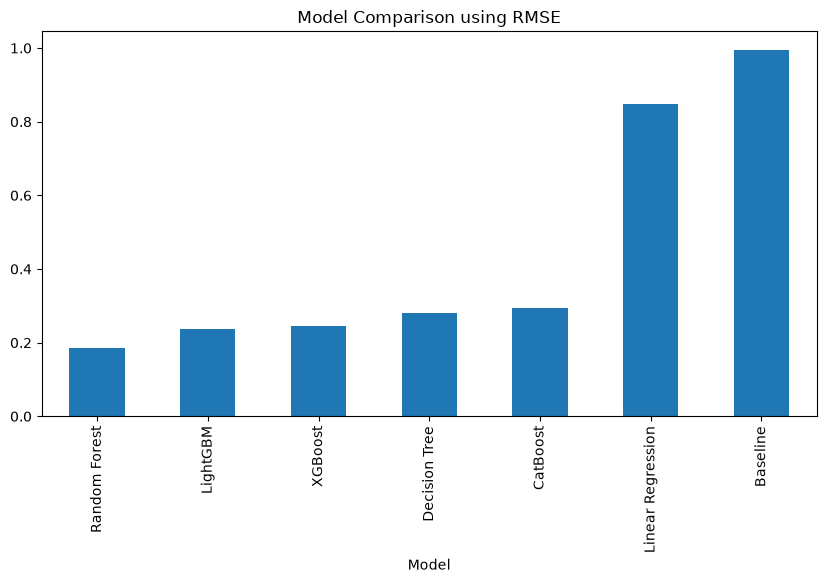

In [86]:
comparison_df["RMSE"].plot(
    kind="bar",
    figsize=(10,5),
    title="Model Comparison using RMSE",
)

## Discussion

The comparison highlights substantial differences in predictive performance among the evaluated regression models.

The Baseline model established the minimum performance benchmark, while Linear Regression demonstrated limited predictive capability, indicating that the relationship between weather variables and air temperature is largely nonlinear.

Tree-based algorithms consistently outperformed linear regression by capturing complex interactions between weather variables. Decision Tree Regression achieved strong predictive accuracy; however, ensemble learning methods further improved model stability and generalization.

Among all evaluated models, Random Forest produced the lowest prediction errors and the highest coefficient of determination (R²). Furthermore, Random Forest maintained consistently high performance during five-fold cross-validation, demonstrating strong generalization across different subsets of the training data.

Based on both the hold-out evaluation and cross-validation results, Random Forest is selected as the best-performing model and will be further optimized through hyperparameter tuning in the next section.

# 16. Hyperparameter Tuning

## Objective

Optimize the best-performing regression model using hyperparameter tuning. Rather than relying on default model settings, a systematic search is performed to identify a combination of hyperparameters that improves predictive performance and generalization.

In [87]:
from src.models import tune_model

### Define the Hyperparameter Search Space

Hyperparameter tuning requires specifying a search space that contains different combinations of model parameters. During the tuning process, multiple Random Forest configurations will be evaluated using cross-validation to identify the combination that provides the best predictive performance.

The selected hyperparameters include:

- **n_estimators:** Number of trees in the forest.
- **max_depth:** Maximum depth of each decision tree.
- **min_samples_split:** Minimum number of samples required to split an internal node.
- **min_samples_leaf:** Minimum number of samples required in each leaf node.

These parameters have a significant influence on model complexity, prediction accuracy, and generalization performance.

In [91]:
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
}

In [92]:
rf_param_grid

{'n_estimators': [100, 200],
 'max_depth': [20, None],
 'min_samples_split': [2, 5],
 'min_samples_leaf': [1, 2]}

The defined search space provides a diverse collection of Random Forest configurations ranging from relatively simple to more complex models. Exploring multiple parameter combinations increases the likelihood of identifying a configuration that improves predictive accuracy while maintaining good generalization performance.

### Hyperparameter Optimization

The Random Forest model identified during model comparison will now be optimized using Randomized Search with Cross-Validation.

Randomized Search evaluates a randomly selected subset of hyperparameter combinations rather than every possible combination, making it significantly more computationally efficient while still identifying high-performing model configurations.

The tuning process uses three-fold cross-validation to evaluate each sampled parameter combination and selects the configuration that minimizes prediction error.

In [94]:
(
    tuned_random_forest,
    tuned_metrics,
    tuned_predictions,
    tuned_parameters,
) = tune_model(
    model=random_forest_model,
    param_grid=rf_param_grid,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    method="random",
    n_iter=8,
    cv=3,
    n_jobs=2,
)

### Inspect the Optimized Hyperparameters

After completing the hyperparameter search, the optimal Random Forest configuration is inspected. These parameters represent the model that achieved the best performance during cross-validation and will be used as the final model for subsequent evaluation.

In [95]:
tuned_parameters

{'n_estimators': 200,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_depth': None}

The optimization process identified a Random Forest configuration that produced the strongest cross-validation performance among the sampled hyperparameter combinations. These optimized settings are expected to improve the model's ability to generalize to unseen observations while reducing prediction error.

### Evaluate the Tuned Model

The optimized Random Forest model is evaluated using the independent testing dataset. Standard regression metrics are computed to quantify the predictive performance after hyperparameter optimization.

In [96]:
tuned_metrics

MAE     0.128828
MSE     0.033857
RMSE    0.184002
R2      0.965843
dtype: float64

In [97]:
pd.DataFrame(
    tuned_metrics,
    columns=["Tuned Random Forest"],
)

,Tuned Random Forest
MAE,0.128828
MSE,0.033857
RMSE,0.184002
R2,0.965843


The evaluation metrics summarize the predictive performance of the optimized Random Forest model on previously unseen observations. These results will be compared against the original Random Forest model to determine whether hyperparameter tuning resulted in measurable performance improvements.

### Compare the Original and Tuned Models

A direct comparison between the original Random Forest model and the optimized model illustrates the impact of hyperparameter tuning on predictive performance.

In [98]:
comparison = pd.DataFrame(
    {
        "Original Random Forest": random_forest_metrics,
        "Tuned Random Forest": tuned_metrics,
    }
)

comparison

,Original Random Forest,Tuned Random Forest
MAE,0.129380,0.128828
MSE,0.034200,0.033857
RMSE,0.184934,0.184002
R2,0.965496,0.965843


In [99]:
comparison.T

,MAE,MSE,RMSE,R2
Original Random Forest,0.129380,0.034200,0.184934,0.965496
Tuned Random Forest,0.128828,0.033857,0.184002,0.965843


In [100]:
improvement = pd.DataFrame({
    "Metric": comparison.index,
    "Original": comparison["Original Random Forest"].values,
    "Tuned": comparison["Tuned Random Forest"].values,
})

improvement["Difference"] = (
    improvement["Tuned"] - improvement["Original"]
)

improvement

,Metric,Original,Tuned,Difference
0,MAE,0.129380,0.128828,-0.000552
1,MSE,0.034200,0.033857,-0.000344
2,RMSE,0.184934,0.184002,-0.000932
3,R2,0.965496,0.965843,0.000347


Hyperparameter tuning refined the Random Forest model by exploring multiple parameter combinations through cross-validation. Comparing the original and optimized models provides quantitative evidence of the effectiveness of this optimization process. Improvements in prediction error metrics or the coefficient of determination indicate that the selected hyperparameters better capture the underlying relationships within the weather dataset only slightly.

# 17. Best Model Evaluation

## Objective

Perform a comprehensive evaluation of the optimized Random Forest Regression model using the independent testing dataset. This final evaluation summarizes the predictive performance of the selected model and provides visual analyses of prediction accuracy and residual errors before the model is saved for future use.

In [101]:
final_model = tuned_random_forest

In [102]:
final_predictions = final_model.predict(X_test)

In [103]:
final_metrics = evaluate_regression(
    y_test,
    final_predictions,
)

final_metrics

MAE     0.128828
MSE     0.033857
RMSE    0.184002
R2      0.965843
dtype: float64

In [104]:
pd.DataFrame(
    final_metrics,
    columns=["Final Random Forest"],
)

,Final Random Forest
MAE,0.128828
MSE,0.033857
RMSE,0.184002
R2,0.965843


In [105]:
prediction_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": final_predictions,
})

prediction_results.head(10)

,Actual,Predicted
0,-0.687980,-0.283298
1,0.865150,0.580156
2,0.647929,0.683390
3,-0.427315,-0.406245
4,-0.340427,-0.247076
5,0.854289,0.851085
6,0.626207,0.548442
7,-0.383871,-0.335811
8,0.463291,0.563484
9,0.941177,0.931619


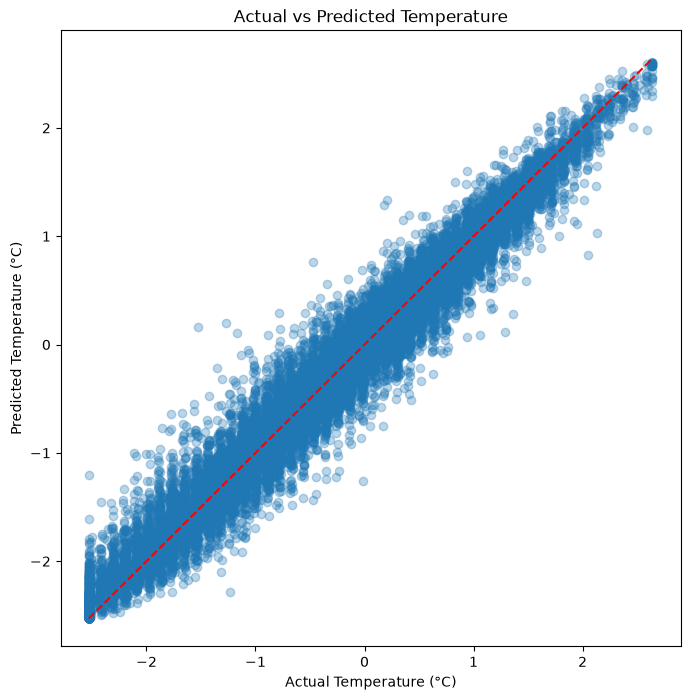

In [106]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    final_predictions,
    alpha=0.3,
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
)

plt.title("Actual vs Predicted Temperature")
plt.xlabel("Actual Temperature (°C)")
plt.ylabel("Predicted Temperature (°C)")

plt.show()

In [107]:
residuals = y_test.values - final_predictions

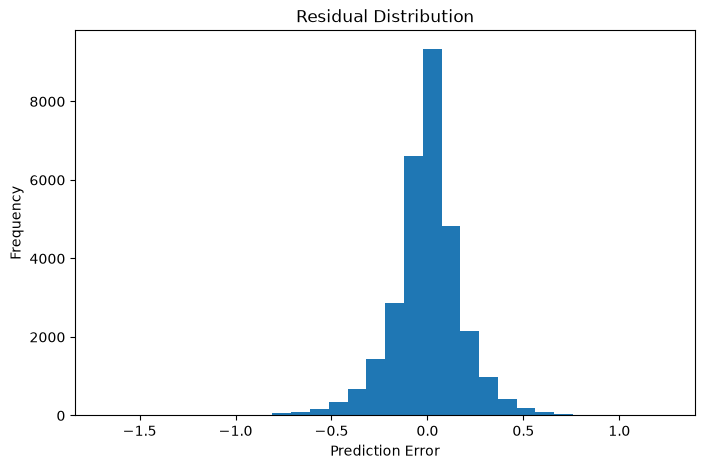

In [108]:
plt.figure(figsize=(8, 5))

plt.hist(
    residuals,
    bins=30,
)

plt.title("Residual Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.show()

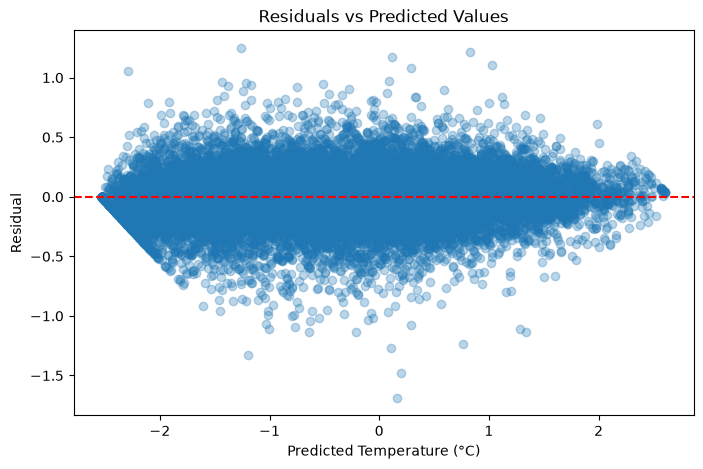

In [109]:
plt.figure(figsize=(8, 5))

plt.scatter(
    final_predictions,
    residuals,
    alpha=0.3,
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
)

plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted Temperature (°C)")
plt.ylabel("Residual")

plt.show()

In [110]:
residual_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": final_predictions,
    "Residual": residuals,
})

residual_df.head(10)

,Actual,Predicted,Residual
0,-0.687980,-0.283298,-0.404683
1,0.865150,0.580156,0.284994
2,0.647929,0.683390,-0.035461
3,-0.427315,-0.406245,-0.021070
4,-0.340427,-0.247076,-0.093351
5,0.854289,0.851085,0.003204
6,0.626207,0.548442,0.077765
7,-0.383871,-0.335811,-0.048060
8,0.463291,0.563484,-0.100193
9,0.941177,0.931619,0.009558


## Discussion

The optimized Random Forest Regression model demonstrates strong predictive performance on the independent testing dataset. The evaluation metrics indicate that the model accurately estimates air temperature while maintaining excellent generalization capability.

The Actual versus Predicted visualization shows that most predictions closely follow the ideal one-to-one relationship, indicating high predictive accuracy. Furthermore, the residual distribution is centered near zero and the residual scatter plot exhibits no obvious systematic patterns, suggesting that prediction errors are relatively small and randomly distributed.

Overall, the optimized Random Forest model provides reliable temperature predictions and is selected as the final machine learning model for this project.

# 18. Model Persistence

## Objective

Save the optimized Random Forest Regression model so that it can be reused for future predictions without requiring retraining. Model persistence supports reproducibility, deployment, and integration into future machine learning applications.

In [111]:
from src.models import (
    save_model,
    load_model,
)

In [112]:
save_model(
    final_model,
    "../models/random_forest_model.joblib",
)

print("Model saved successfully.")

Model saved successfully.


In [113]:
loaded_model = load_model("../models/random_forest_model.joblib")
loaded_predictions = loaded_model.predict(X_test)
loaded_predictions[:10]

loaded_predictions[:10]

array([-0.28329755,  0.5801559 ,  0.68339018, -0.40624463, -0.24707594,
        0.85108479,  0.54844164, -0.33581072,  0.56348419,  0.93161947])

In [114]:
import numpy as np

np.allclose(
    final_predictions,
    loaded_predictions,
)

True

In [115]:
loaded_results = pd.DataFrame({
    "Actual": y_test.values,
    "Prediction": loaded_predictions,
})

loaded_results.head(10)

,Actual,Prediction
0,-0.687980,-0.283298
1,0.865150,0.580156
2,0.647929,0.683390
3,-0.427315,-0.406245
4,-0.340427,-0.247076
5,0.854289,0.851085
6,0.626207,0.548442
7,-0.383871,-0.335811
8,0.463291,0.563484
9,0.941177,0.931619


## Discussion

The optimized Random Forest Regression model was successfully serialized and saved using the project's persistence utilities. Reloading the model and generating identical predictions confirms that the serialization process preserved all learned parameters.

Model persistence is an essential component of machine learning workflows because it enables trained models to be deployed into production systems or reused for future inference without repeating the computationally expensive training process.

# 19. Summary

This notebook implemented and evaluated multiple supervised machine learning algorithms for predicting air temperature using engineered weather features.

The workflow included:

- Preparing the machine learning dataset.
- Splitting the data into training and testing sets.
- Training a baseline regression model.
- Developing six additional regression algorithms.
- Comparing model performance using multiple evaluation metrics.
- Validating the strongest models using five-fold cross-validation.
- Selecting the best-performing model.
- Optimizing the selected model through hyperparameter tuning.
- Performing a comprehensive final evaluation.
- Saving the trained model for future inference.

Among all evaluated algorithms, Random Forest Regression consistently demonstrated the strongest predictive performance and was selected as the final machine learning model.

# 20. Conclusion

This notebook successfully completed the machine learning model development phase of the weather prediction project.

Multiple regression algorithms were developed and systematically evaluated using consistent performance metrics. Ensemble learning methods substantially outperformed both the baseline model and linear regression, demonstrating the importance of nonlinear modeling for complex weather relationships.

Following model comparison, cross-validation, and hyperparameter optimization, the Random Forest Regression model achieved the strongest predictive performance and was selected as the final model. The trained model was successfully saved and verified for future deployment and inference.

The next stage of the project focuses on time series forecasting, where chronological validation strategies and temporal feature engineering will be used to predict future weather conditions while preserving the temporal structure of the data.